# Bind Score — End-to-End Exploration

This notebook walks through the full bind-score pipeline:

1. **EDA** — understand submissions, events, and bind rate
2. **Features** — four time-bounded features at `t ∈ {0, 7, 30}`
3. **Training** — temporal split, model comparison, evaluation metrics
4. **Feature significance** — permutation importance by horizon
5. **Scoring** — `bind_score(submission_id, t)` API
6. **Challenges & future work** — limitations and path to production

**Run the first code cell before any other** — it adds the repo root to `sys.path` so `import src` works.

Launch from the repository root (Git Bash):

```bash
export PATH="$HOME/.local/bin:$PATH"
uv sync
uv run jupyter notebook notebooks/exploration.ipynb
```

Use the project's `.venv` kernel (via `uv run jupyter` above). See [README.md](../README.md) for design rationale.

In [109]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    """Locate repo root whether the kernel cwd is repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find project root. Start Jupyter from the repo root or notebooks/ folder."
    )


def reload_project_modules() -> None:
    """Reload src.* modules so the notebook picks up code changes without a kernel restart."""
    import src.paths as paths
    import src.config as config
    import src.data_loader as data_loader
    import src.features as features
    import src.train as train
    import src.evaluate as evaluate
    import src.bind_score as bind_score

    for mod in (paths, config, data_loader, features, train, evaluate, bind_score):
        importlib.reload(mod)


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

reload_project_modules()
from src.paths import DATA_DIR, MODELS_DIR, OUTPUT_DIR

plt.rcParams["figure.figsize"] = (10, 4)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: C:\Users\galin\CascadeProjects\novella
Data dir:     C:\Users\galin\CascadeProjects\novella\data
Models dir:   C:\Users\galin\CascadeProjects\novella\models
Output dir:   C:\Users\galin\CascadeProjects\novella\output


## 1. Load data & exploratory analysis

Data files use actual CSV column names (`event_date`, `event_type`, `QUOTE_RECEIVED`).

In [110]:
from src.data_loader import load_data
from src.config import HORIZONS

submissions, events = load_data()

print(f"Submissions: {len(submissions):,}")
print(f"Events: {len(events):,}")
print(f"Bind rate: {submissions['label'].mean():.1%}")
print(f"Unique agents: {submissions['agentEmail'].nunique():,}")

submissions.head()

Submissions: 881
Events: 17,211
Bind rate: 14.8%
Unique agents: 397


,submissionId,createdDate,resolvedDate,agentEmail,label
submissionId,,,,,
1,1,2020-01-01 00:00:00,2020-02-11 08:19:16,1@gmail.com,0
2,2,2020-01-01 04:08:26,2020-01-15 03:01:10,2@gmail.com,0
3,3,2020-01-01 05:54:25,2020-01-09 01:41:13,3@gmail.com,0
4,4,2020-01-01 06:56:10,2020-01-22 03:26:08,4@gmail.com,0
5,5,2020-01-01 07:04:16,2020-01-10 01:35:32,5@gmail.com,0


### 1a. Bind rate — class imbalance baseline

`submissions['label'].mean()` on a 0/1 target is the **fraction sold** (bind rate / positive-class prevalence). Formatting with `:.1%` prints it as a percentage (~14.8%).

Why it matters here:

- A model that always predicts “won’t bind” is ~85% accurate but useless.
- Our primary evaluation metric — **precision @ top 20%** — is compared to this baseline (~15%): a good bind score should enrich the broker’s top-ranked queue above random sampling.
- F4 (agent smoothed bind rate) shrinks toward this global rate when an agent has little history.

See **§3** for why we use P@20 and PR-AUC instead of accuracy or ROC-AUC alone.

### 1b. Missing & null value checks

**Philosophy:** treat missingness as **information**, not noise to erase. We only fill values where the schema says a field is inapplicable (e.g. email metrics on a quote event), or where a stable sentinel is needed for grouping (agent email). We do **not** impute labels, dates, or submission outcomes, and we do **not** drop submissions with sparse event history.

**Load-time rules** (`src/data_loader.py` — applied before features or training):

| Column | Raw issue | Handling | Why |
|--------|-----------|----------|-----|
| `agentEmail` | none in current data | `NaN` → `"unknown"` | Defensive; keeps F4 grouping defined |
| `email_char_count`, `email_attachment_count` | all 1,144 `QUOTE_RECEIVED` rows null | `NaN` → `0` | Field is N/A for quotes, not “unknown email size” |
| `createdDate`, `resolvedDate`, `event_date` | none missing | strict parse | Temporal splits and leakage rules depend on exact dates |
| `label` | none missing | cast to int | Target — never imputed |

**What we deliberately do not do:**
- Impute bind labels or resolution dates
- Drop the 5 submissions with zero events (F3 = 0; F1/F2 use missing-signal rules in §2)
- Use a generic sklearn `SimpleImputer` on the feature matrix

In [111]:
reload_project_modules()
from src.data_loader import audit_raw_data, audit_loaded_data, load_data

raw_audit = audit_raw_data()
print("Raw CSV — null / empty counts")
raw_issues = raw_audit[(raw_audit["null_count"] > 0) | (raw_audit["empty_string_count"] > 0)]
if raw_issues.empty:
    print("No null or empty-string values in raw files.")
else:
    display(raw_issues.sort_values(["table", "null_count"], ascending=False))

clean_audit = audit_loaded_data(submissions, events)
print("\nAfter loading & imputation — remaining nulls")
clean_nulls = clean_audit[clean_audit["null_count"] > 0]
if clean_nulls.empty:
    print("No remaining null values in cleaned submissions/events tables.")
else:
    display(clean_nulls)

quote_nulls_raw = raw_audit[
    (raw_audit["table"] == "events")
    & raw_audit["column"].isin(["email_char_count", "email_attachment_count"])
]
print("\nEvent email field nulls in raw CSV (expected on QUOTE_RECEIVED):")
display(quote_nulls_raw[["column", "null_count", "null_pct"]])

Raw CSV — null / empty counts


,table,column,rows,null_count,null_pct,empty_string_count,dtype
8,events,email_char_count,17211,1144,0.0665,0,float64
9,events,email_attachment_count,17211,1144,0.0665,0,float64



After loading & imputation — remaining nulls
No remaining null values in cleaned submissions/events tables.

Event email field nulls in raw CSV (expected on QUOTE_RECEIVED):


,column,null_count,null_pct
8,email_char_count,1144,0.0665
9,email_attachment_count,1144,0.0665


In [112]:
from src.paths import SUBMISSIONS_CSV, EVENTS_CSV

submissions_raw = pd.read_csv(SUBMISSIONS_CSV)
events_raw = pd.read_csv(EVENTS_CSV)

checks = pd.DataFrame(
    [
        {"check": "duplicate submissionId (submissions)", "count": int(submissions_raw["submissionId"].duplicated().sum())},
        {"check": "missing resolvedDate (submissions)", "count": int(submissions_raw["resolvedDate"].isna().sum())},
        {"check": "missing createdDate (submissions)", "count": int(submissions_raw["createdDate"].isna().sum())},
        {"check": "missing agentEmail (submissions)", "count": int(submissions_raw["agentEmail"].isna().sum())},
        {
            "check": "submissions with zero events",
            "count": int((~submissions_raw["submissionId"].isin(events_raw["submissionId"])).sum()),
        },
        {"check": "events with null event_type", "count": int(events_raw["event_type"].isna().sum())},
        {"check": "events with null event_date", "count": int(events_raw["event_date"].isna().sum())},
        {
            "check": "QUOTE_RECEIVED with null email_char_count (raw)",
            "count": int(
                events_raw.loc[events_raw["event_type"] == "QUOTE_RECEIVED", "email_char_count"].isna().sum()
            ),
        },
    ]
)
checks["status"] = checks["count"].map(lambda n: "OK" if n == 0 else "review")
print("Structural data quality checks")
checks

Structural data quality checks


,check,count,status
0,duplicate submissionId (submissions),0,OK
1,missing resolvedDate (submissions),0,OK
2,missing createdDate (submissions),0,OK
3,missing agentEmail (submissions),0,OK
4,submissions with zero events,5,review
5,events with null event_type,0,OK
6,events with null event_date,0,OK
7,QUOTE_RECEIVED with null email_char_count (raw),1144,review


### 1c. What the audits tell us

The **raw vs clean** tables above should show:

- **`QUOTE_RECEIVED` email fields:** 100% null in raw CSV → **0 after load**. Status `review` in structural checks is expected, not a data defect.
- **Submissions with zero events (5):** kept in the sample; at feature time they contribute zeros / missing-signal defaults (see §2).
- **Core keys and dates:** no nulls — safe for temporal train/val/test splits.

The next cells explore event mix and resolution timing on the **cleaned** tables returned by `load_data()`.

In [113]:
events["event_type"].value_counts()

event_type
EMAIL_OUTBOUND    9712
EMAIL_INBOUND     6355
QUOTE_RECEIVED    1144
Name: count, dtype: int64

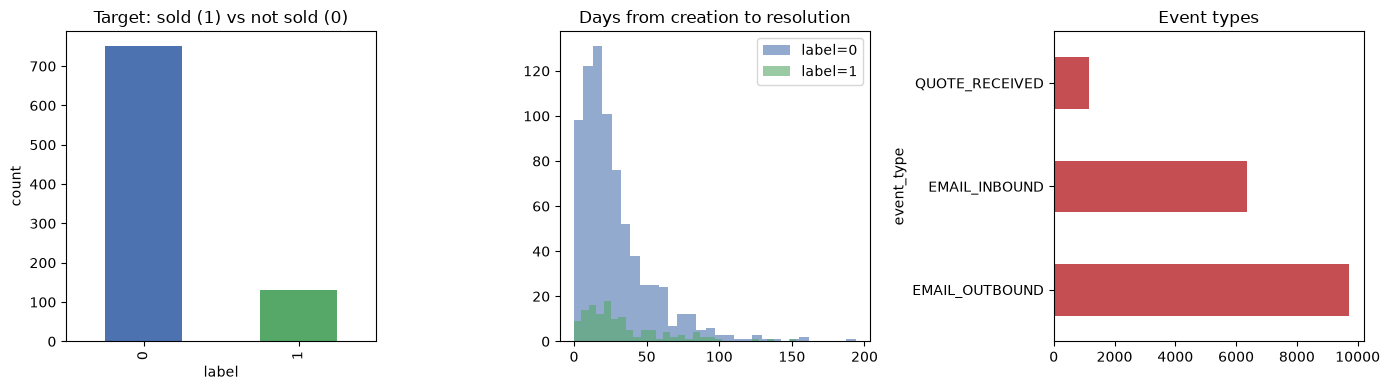

Median days to resolve: 21 (p90=62)


In [114]:
submissions["days_to_resolve"] = (
    submissions["resolvedDate"] - submissions["createdDate"]
).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

submissions["label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"]
)
axes[0].set_title("Target: sold (1) vs not sold (0)")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")

for label, color in [(0, "#4C72B0"), (1, "#55A868")]:
    subset = submissions[submissions["label"] == label]["days_to_resolve"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=f"label={label}", color=color)
axes[1].set_title("Days from creation to resolution")
axes[1].legend()

events["event_type"].value_counts().plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].set_title("Event types")

plt.tight_layout()
plt.show()

print(
    f"Median days to resolve: {submissions['days_to_resolve'].median():.0f} "
    f"(p90={submissions['days_to_resolve'].quantile(0.9):.0f})"
)

### 1d. Days to resolution

`days_to_resolve = resolvedDate − createdDate` — time until the submission **closes** (sold **or** not sold), not “days until bind” for sold cases only.

| Stat | Meaning |
|------|---------|
| **Median = 21** | Half of submissions close within 21 days; half take longer. |
| **p90 = 62** | 90% close within 62 days; the slowest 10% take longer. |

Most activity happens in the first few weeks, which supports scoring at **t ∈ {0, 7, 30}**. The long tail (p90 = 62) means many submissions are still open after day 30 in production — but training features only use events with `event_date ≤ T_ref`, which keeps scoring leakage-safe.

In [115]:
# Pre-creation events: linked to submissionId but before createdDate
sub_cols = submissions.reset_index(drop=True)[["submissionId", "createdDate"]]
merged = events.merge(sub_cols, on="submissionId", how="left")
pre_creation = (merged["event_date"] < merged["createdDate"]).sum()
print(f"Events before createdDate: {pre_creation:,} (included when event_date <= T_ref)")

Events before createdDate: 471 (included when event_date <= T_ref)


### 1e. Pre-creation events and the training set

The 471 pre-creation events are **not** separate training rows. They are folded into features for submissions that already sit in train or test.

**Train vs test** is decided by **`createdDate`** (earliest 80% → train, latest 20% → test), not by event timing. In this dataset, **268** submissions have at least one pre-creation event (~**189** in train, ~**79** in test).

**Why they count toward features:** at horizon `t`, cutoff is `T_ref = createdDate + t`. Pre-creation events have `event_date < createdDate`, so they satisfy `event_date ≤ T_ref` even at **t = 0** — they were already known when scoring on creation day. That is intentional signal (email thread before formal submission), not leakage.

## 2. Time-bounded features

### What is `T_ref`?

**`T_ref`** is the scoring cutoff: “pretend we are at **`createdDate + t` days**.” Everything used in features must be knowable at or before that moment.

\[
T_{\text{ref}} = \text{createdDate} + t \text{ days}
\]

| Horizon `t` | Example (`createdDate = 2020-01-01`) | What counts |
|-------------|--------------------------------------|-------------|
| 0 | 2020-01-01 | Creation-day activity only |
| 7 | 2020-01-08 | First week |
| 30 | 2020-01-31 | First ~month |

| Data | Inclusion rule |
|------|----------------|
| Events (F1–F3) | `event_date ≤ T_ref` |
| Agent bind rate (F4) | submissions with `resolvedDate < T_ref` only |

Events after `T_ref` are ignored for that score. Pre-creation events still count when `event_date ≤ T_ref` (see §1e).

### Four features (summary)

| Feature | Signal | One-line definition |
|---------|--------|---------------------|
| F1 `inbound_recency_days` | Engagement velocity | Days since last broker inbound email |
| F2 `quote_received_flag` | Underwriting milestone | Quote received by `T_ref`? (0/1) |
| F3 `cumulative_email_density` | Information intensity | Total email chars + 100 × attachments |
| F4 `agent_smoothed_bind_rate` | Broker quality | Agent historical bind rate, smoothed |

**§2a below** walks through each feature: formula, missing-data rule, and why it helps predict binding. Implementation lives in `src/features.py`; constants in `src/config.py`.

### 2a. Feature engineering — definitions

All four features are computed in `compute_features()` using only data available at `T_ref`. The same logic powers `feature(submission_id, t)` and the training pipeline.

---

#### F1 — `inbound_recency_days` (engagement velocity)

**Question answered:** How recently did the broker last email us?

**Computation:** Among `EMAIL_INBOUND` events with `event_date ≤ T_ref`, take the most recent date and compute:

\[
\text{F1} = T_{\text{ref}} - \max(\text{event\_date of inbound emails})
\]

**Interpretation:** Lower values mean fresher broker engagement (often associated with higher bind probability). Outbound emails and quotes are not used for F1.

**If no inbound email by `T_ref`:** set F1 = **`t + 30`** (`INBOUND_RECENCY_MISSING_DAYS`). This is a deliberate “silence penalty” — larger than any real recency — and adding 30 (not just `t`) keeps the sentinel distinct across horizons.

---

#### F2 — `quote_received_flag` (underwriting milestone)

**Question answered:** Has underwriting produced a quote yet?

**Computation:**

\[
\text{F2} = \begin{cases} 1 & \text{if any `QUOTE_RECEIVED` event with `event_date ≤ T_ref`} \\ 0 & \text{otherwise} \end{cases}
\]

**Interpretation:** A binary milestone flag. Receiving a quote is a strong step toward binding; at early horizons many submissions are still 0.

**If no quote by `T_ref`:** F2 = **0** (explicit “not yet quoted”, not missing).

---

#### F3 — `cumulative_email_density` (information intensity)

**Question answered:** How much email content has accumulated on this submission so far?

**Computation:** Sum over **all** event types with `event_date ≤ T_ref`:

\[
\text{F3} = \sum \text{email\_char\_count} + 100 \times \sum \text{email\_attachment\_count}
\]

**Attachment weight = 100** (`ATTACHMENT_WEIGHT`): early emails have median ~300 characters and ~1 attachment; weighting puts attachments on a similar scale to body text.

**Note:** `QUOTE_RECEIVED` rows contribute 0 to both sums after load-time imputation (email fields are N/A for quotes). Pre-creation events count if `event_date ≤ T_ref`.

**If no events (or only zero-contribution rows) by `T_ref`:** F3 = **0**.

---

#### F4 — `agent_smoothed_bind_rate` (broker quality)

**Question answered:** Historically, how often does this broker’s submissions bind?

**Computation:**

1. Find this submission’s `agentEmail`.
2. Collect **other** submissions by the same agent with **`resolvedDate < T_ref`** (already closed before scoring time). The current submission is **not** included.
3. Let `binds = sum(label)`, `n = count`, and `global_rate` = bind rate of all submissions with `resolvedDate < T_ref`.
4. Apply smoothing with **α = 10** (`SMOOTHING_ALPHA`):

\[
\text{F4} = \frac{\text{binds} + \alpha \cdot \text{global\_rate}}{n + \alpha}
\]

**Why smooth?** With 397 unique agents, raw rates are unstable (one bind out of one submission → 100%). Smoothing shrinks sparse agents toward the global rate (~15%) until enough history exists.

**Examples** (global rate ≈ 0.15, α = 10):

| Agent history | F4 |
|---------------|-----|
| 0 prior resolved submissions | 0.15 (global rate) |
| 10 prior, 2 binds | (2 + 1.5) / 20 = **0.175** |
| 50 prior, 10 binds | (10 + 1.5) / 60 ≈ **0.19** |

**Leakage safety:** Only outcomes known before `T_ref` enter the calculation. F4 is typically the **strongest** predictor in permutation-importance rankings (see §5).

---

#### Quick reference — missing-signal defaults

| Feature | Condition | Value |
|---------|-----------|-------|
| F1 | No inbound email by `T_ref` | `t + 30` |
| F2 | No quote by `T_ref` | `0` |
| F3 | No contributing events by `T_ref` | `0` |
| F4 | Agent has little/no history before `T_ref` | Shrinks toward global bind rate |

In [116]:
from src.features import feature, build_feature_frame, compute_features
from src.config import FEATURE_NAMES

SAMPLE_ID = 1
feature_rows = []
for t in HORIZONS:
    feats = feature(SAMPLE_ID, t)
    feature_rows.append({"t": t, **feats})

pd.DataFrame(feature_rows).set_index("t")

,inbound_recency_days,quote_received_flag,cumulative_email_density,agent_smoothed_bind_rate
t,,,,
0,0.000069,0.0,1805.0,0.147560
7,1.916910,1.0,7025.0,0.500000
30,2.937095,1.0,9942.0,0.078947


In [117]:
feature_frame = build_feature_frame(submissions, events)
print(f"Feature matrix: {feature_frame.shape[0]:,} rows = {len(submissions)} submissions × {len(HORIZONS)} horizons")
feature_frame.head(6)

Feature matrix: 2,643 rows = 881 submissions × 3 horizons


,submissionId,t,createdDate,label,inbound_recency_days,quote_received_flag,cumulative_email_density,agent_smoothed_bind_rate
0,1,0,2020-01-01 00:00:00,0,0.000069,0.0,1805.0,0.147560
1,1,7,2020-01-01 00:00:00,0,1.916910,1.0,7025.0,0.500000
2,1,30,2020-01-01 00:00:00,0,2.937095,1.0,9942.0,0.078947
3,2,0,2020-01-01 04:08:26,0,30.000000,0.0,0.0,0.147560
4,2,7,2020-01-01 04:08:26,0,4.943391,0.0,4975.0,0.500000
5,2,30,2020-01-01 04:08:26,0,20.951030,1.0,9222.0,0.071770


### 2b. Feature EDA — summary statistics & distributions

For each engineered feature and horizon `t`, we report:
- **Descriptive stats** (mean, std, quartiles) on the full sample
- **Mean by outcome** (label 0 vs 1) and the difference — a simple univariate signal check
- **Distribution plots** — histograms overlaid by sold / not sold
- **Boxplots** — sold vs not sold at all horizons side by side

**Color key (histograms and boxplots):** blue = not sold (label 0), green = sold (label 1).

**Histogram text box (μ sold / μ not / Δ):** mean feature value for sold vs not sold, and Δ = μ sold − μ not. A large |Δ| means the feature separates outcomes on its own at that horizon (not model importance).

**Boxplot outliers (dots beyond the whiskers):** individual submissions whose feature value falls outside the Tukey fence (below Q1 − 1.5×IQR or above Q3 + 1.5×IQR) for that horizon × outcome group. Dots use the **same color as their box** — they are extreme values in that group, not mislabeled rows. Examples: very high F1 (often imputed `t+30`), heavy F3 email threads, unusual F4 agent history. On **F2** (0/1), the minority class often plots as outliers; read F2 from the histogram instead.

**Reading missingness in the plots:**
- **F1:** spikes at `t+30` (37, 44, 74 for t=0,7,30) mark submissions with no inbound email yet — by design, not load imputation.
- **F2:** mass at 0 = no quote by horizon; 1 = quote received.
- **F3:** mass at 0 includes zero-event submissions and early horizons before email activity.
- **F4:** compressed range for new agents reflects smoothing toward the global bind rate (~15%).

In [118]:
FEATURE_LABELS = {
    "inbound_recency_days": "F1 inbound recency (days)",
    "quote_received_flag": "F2 quote received",
    "cumulative_email_density": "F3 email density",
    "agent_smoothed_bind_rate": "F4 agent bind rate",
}

stats_rows = []
for t in HORIZONS:
    subset = feature_frame[feature_frame["t"] == t]
    for col in FEATURE_NAMES:
        desc = subset[col].describe()
        mean_0 = subset.loc[subset["label"] == 0, col].mean()
        mean_1 = subset.loc[subset["label"] == 1, col].mean()
        stats_rows.append(
            {
                "t": t,
                "feature": col,
                "count": int(desc["count"]),
                "mean": desc["mean"],
                "std": desc["std"],
                "min": desc["min"],
                "p25": desc["25%"],
                "median": desc["50%"],
                "p75": desc["75%"],
                "max": desc["max"],
                "mean_not_sold": mean_0,
                "mean_sold": mean_1,
                "mean_diff_sold_minus_not": mean_1 - mean_0,
                "pct_nonzero": (subset[col] != 0).mean(),
            }
        )

feature_stats = pd.DataFrame(stats_rows)
num_cols = [
    "mean", "std", "min", "p25", "median", "p75", "max",
    "mean_not_sold", "mean_sold", "mean_diff_sold_minus_not",
]
feature_stats[num_cols] = feature_stats[num_cols].round(3)
feature_stats["pct_nonzero"] = feature_stats["pct_nonzero"].round(3)

print("Summary statistics per feature and horizon")
feature_stats.set_index(["t", "feature"])[
    ["count", "mean", "std", "median", "p25", "p75", "min", "max", "mean_not_sold", "mean_sold", "mean_diff_sold_minus_not", "pct_nonzero"]
]

Summary statistics per feature and horizon


count      mean        std    median       p25  \
t  feature                                                                    
0  inbound_recency_days        881    21.269     13.754    30.000     0.001   
   quote_received_flag         881     0.000      0.000     0.000     0.000   
   cumulative_email_density    881   755.476   2873.076     0.000     0.000   
   agent_smoothed_bind_rate    881     0.167      0.136     0.146     0.133   
7  inbound_recency_days        881    11.316     14.179     5.858     2.007   
   quote_received_flag         881     0.412      0.492     0.000     0.000   
   cumulative_email_density    881  5420.953   6959.418  3448.000  1928.000   
   agent_smoothed_bind_rate    881     0.148      0.057     0.143     0.127   
30 inbound_recency_days        881    24.422     17.866    22.099    11.892   
   quote_received_flag         881     0.579      0.494     1.000     0.000   
   cumulative_email_density    881  9656.469  18265.997  5736.000  2893.000   
   agent_smoothed_bind_rate    881     0.145      0.059     0.133     0.118   

                                   p75    min         max  mean_not_sold  \
t  feature                                                                 
0  inbound_recency_days         30.000  0.000      80.974         21.337   
   quote_received_flag           0.000  0.000       0.000          0.000   
   cumulative_email_density    809.000  0.000   48422.000        678.732   
   agent_smoothed_bind_rate      0.155  0.029       1.000          0.164   
7  inbound_recency_days          7.000  0.001      87.974         11.237   
   quote_received_flag           1.000  0.000       1.000          0.379   
   cumulative_email_density   6270.000  0.000   95215.000       5081.961   
   agent_smoothed_bind_rate      0.155  0.027       0.500          0.143   
30 inbound_recency_days         29.338  0.006      60.000         25.087   
   quote_received_flag           1.000  0.000       1.000          0.530   
   cumulative_email_density  11079.000  0.000  426834.000       8043.899   
   agent_smoothed_bind_rate      0.153  0.028       0.420          0.133   

                             mean_sold  mean_diff_sold_minus_not  pct_nonzero  
t  feature                                                                     
0  inbound_recency_days         20.878                    -0.459        1.000  
   quote_received_flag           0.000                     0.000        0.000  
   cumulative_email_density   1198.815                   520.083        0.304  
   agent_smoothed_bind_rate      0.185                     0.022        1.000  
7  inbound_recency_days         11.772                     0.535        1.000  
   quote_received_flag           0.600                     0.221        0.412  
   cumulative_email_density   7379.285                  2297.323        0.978  
   agent_smoothed_bind_rate      0.179                     0.037        1.000  
30 inbound_recency_days         20.583                    -4.504        1.000  
   quote_received_flag           0.862                     0.332        0.579  
   cumulative_email_density  18972.162                 10928.263        0.991  
   agent_smoothed_bind_rate      0.216                     0.083        1.000

In [119]:
mean_by_label = feature_stats.pivot(index="feature", columns="t", values="mean_diff_sold_minus_not")
mean_by_label.index = [FEATURE_LABELS.get(f, f) for f in mean_by_label.index]
mean_by_label.columns = [f"t={t}" for t in mean_by_label.columns]
print("Mean difference (sold − not sold) — positive ⇒ higher values among sold submissions")
mean_by_label.round(3)

Mean difference (sold − not sold) — positive ⇒ higher values among sold submissions


,t=0,t=7,t=30
F4 agent bind rate,0.022,0.037,0.083
F3 email density,520.083,2297.323,10928.263
F1 inbound recency (days),-0.459,0.535,-4.504
F2 quote received,0.000,0.221,0.332


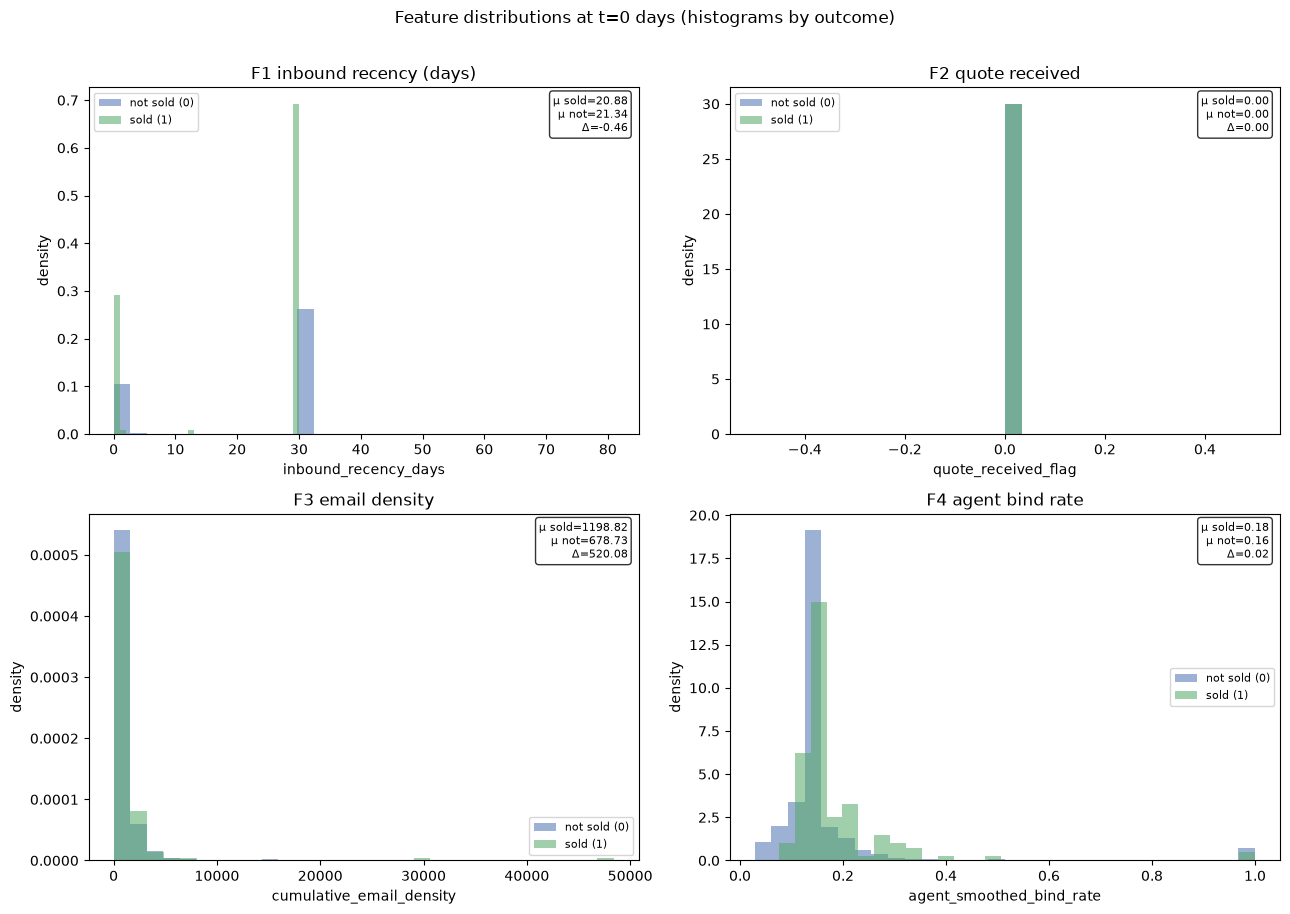

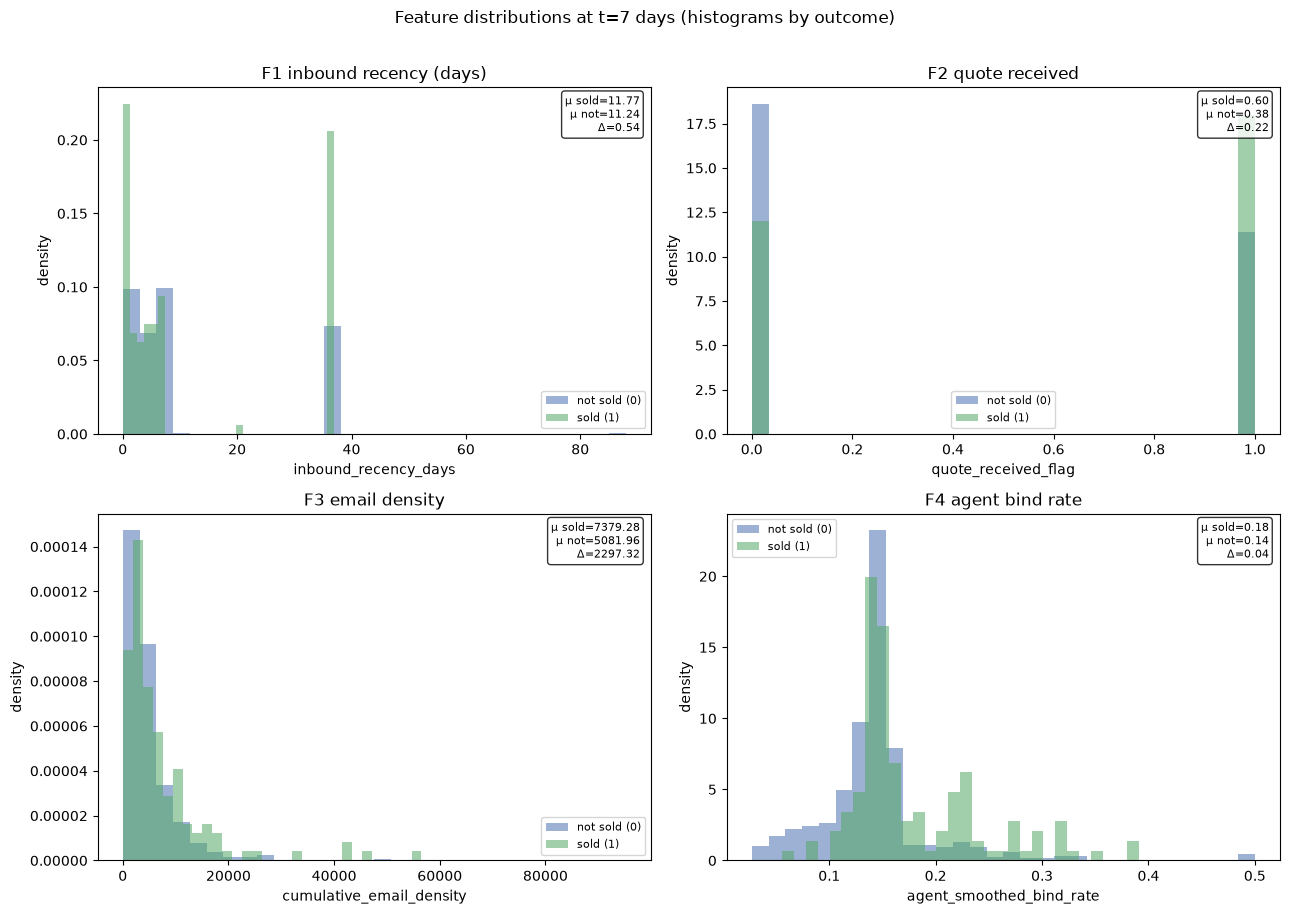

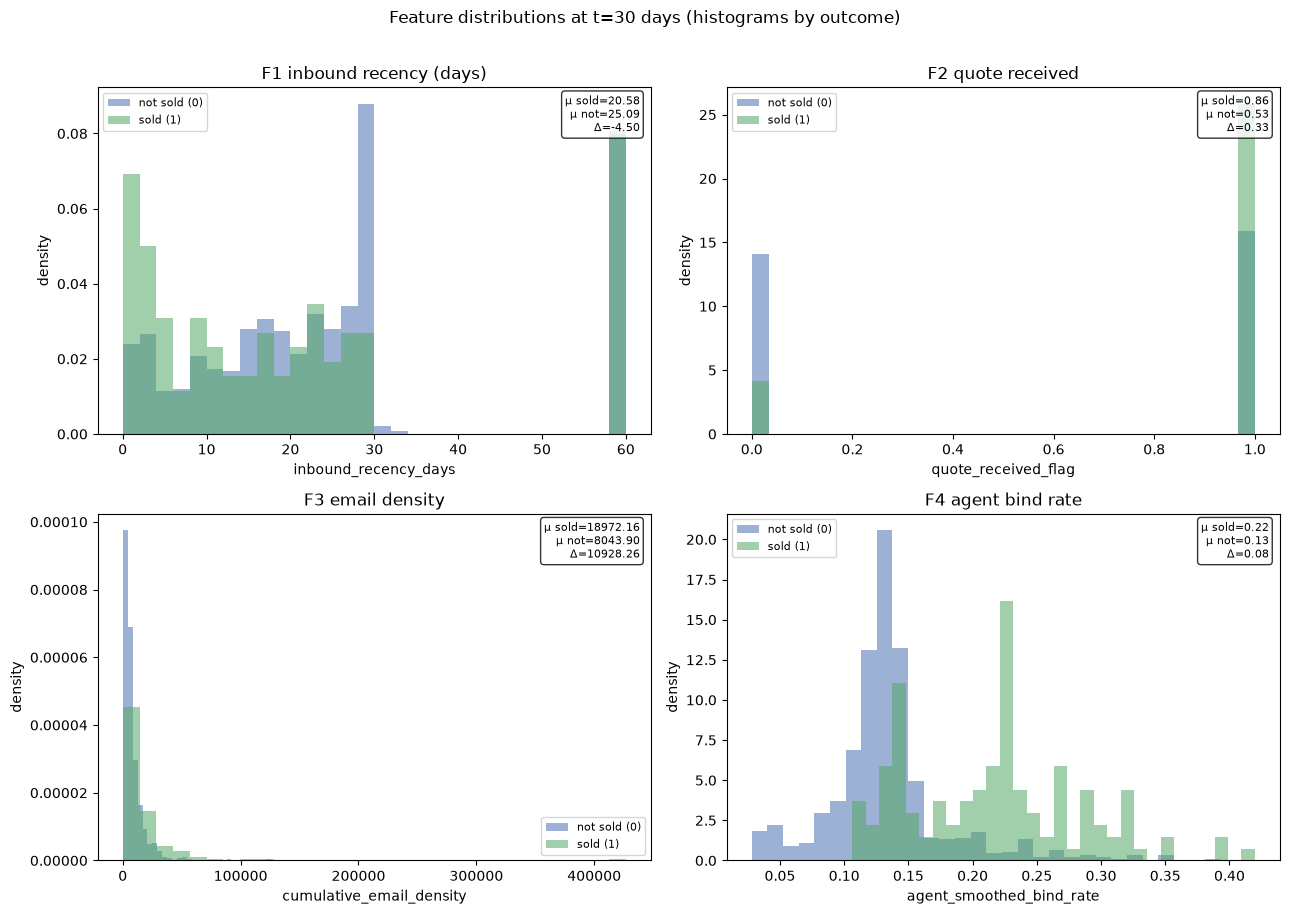

In [120]:
LABEL_COLORS = {0: "#4C72B0", 1: "#55A868"}
LABEL_NAMES = {0: "not sold (0)", 1: "sold (1)"}

for t in HORIZONS:
    subset = feature_frame[feature_frame["t"] == t]
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.ravel()

    for ax, col in zip(axes, FEATURE_NAMES):
        for label in [0, 1]:
            values = subset.loc[subset["label"] == label, col]
            ax.hist(
                values,
                bins=30,
                alpha=0.55,
                density=True,
                label=LABEL_NAMES[label],
                color=LABEL_COLORS[label],
            )
        row = feature_stats[(feature_stats["t"] == t) & (feature_stats["feature"] == col)].iloc[0]
        ax.set_title(FEATURE_LABELS[col])
        ax.set_xlabel(col)
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
        ax.text(
            0.98,
            0.98,
            f"μ sold={row['mean_sold']:.2f}\nμ not={row['mean_not_sold']:.2f}\nΔ={row['mean_diff_sold_minus_not']:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

    fig.suptitle(f"Feature distributions at t={t} days (histograms by outcome)", y=1.01)
    plt.tight_layout()
    plt.show()

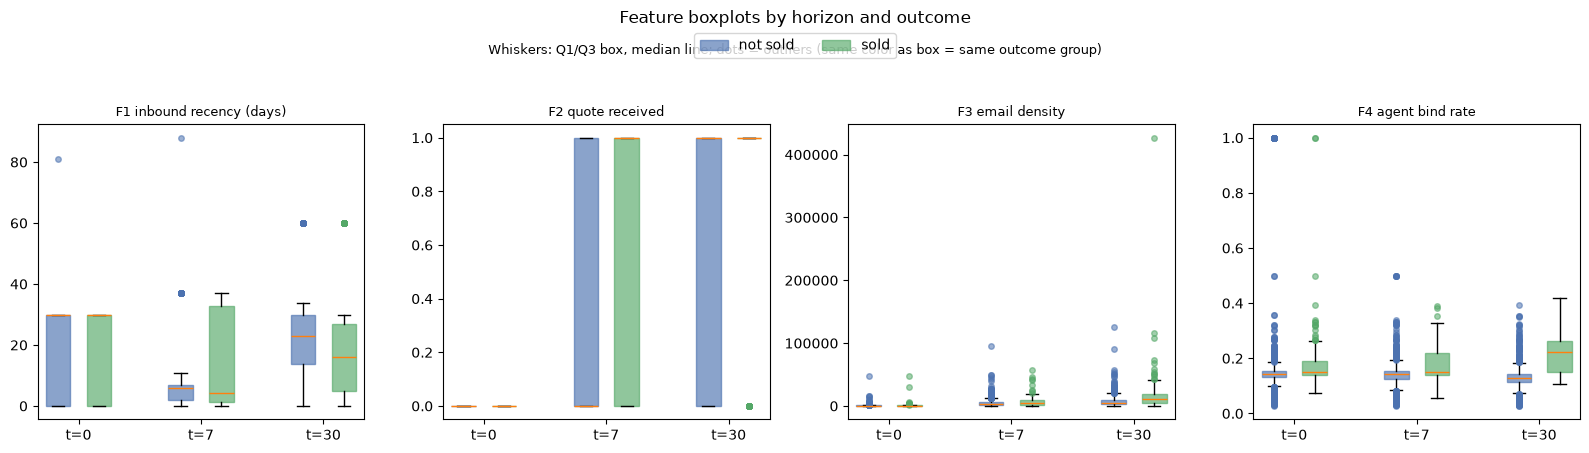

In [121]:
# Boxplots — compare sold vs not sold per feature (all horizons side by side)
# Outliers = submissions outside Q1 - 1.5*IQR or Q3 + 1.5*IQR for that horizon x label group.
plot_rows = []
for t in HORIZONS:
    chunk = feature_frame[feature_frame["t"] == t].copy()
    chunk["horizon"] = f"t={t}"
    plot_rows.append(chunk)
plot_df = pd.concat(plot_rows, ignore_index=True)

fig, axes = plt.subplots(1, len(FEATURE_NAMES), figsize=(16, 4), sharey=False)
for ax, col in zip(axes, FEATURE_NAMES):
    data_0 = plot_df[plot_df["label"] == 0]
    data_1 = plot_df[plot_df["label"] == 1]
    positions = []
    box_data = []
    box_labels = []
    tick_labels = []
    for i, t in enumerate(HORIZONS):
        for label, df in [(0, data_0), (1, data_1)]:
            subset = df[df["t"] == t]
            box_data.append(subset[col].values)
            positions.append(i * 3 + label)
            box_labels.append(label)
        tick_labels.append(f"t={t}")

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        flierprops=dict(marker="o", markersize=4, linestyle="none"),
    )
    for patch, label in zip(bp["boxes"], box_labels):
        patch.set_facecolor(LABEL_COLORS[label])
        patch.set_edgecolor(LABEL_COLORS[label])
        patch.set_alpha(0.65)
    for flier, label in zip(bp["fliers"], box_labels):
        flier.set_markerfacecolor(LABEL_COLORS[label])
        flier.set_markeredgecolor(LABEL_COLORS[label])
        flier.set_alpha(0.55)

    ax.set_xticks([i * 3 + 0.5 for i in range(len(HORIZONS))])
    ax.set_xticklabels(tick_labels)
    ax.set_title(FEATURE_LABELS[col], fontsize=9)

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(facecolor=LABEL_COLORS[0], edgecolor=LABEL_COLORS[0], alpha=0.65, label="not sold"),
        Patch(facecolor=LABEL_COLORS[1], edgecolor=LABEL_COLORS[1], alpha=0.65, label="sold"),
    ],
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.08),
)
fig.suptitle("Feature boxplots by horizon and outcome", y=1.12)
fig.text(
    0.5,
    1.01,
    "Whiskers: Q1/Q3 box, median line; dots = outliers (same color as box = same outcome group)",
    ha="center",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 3. Temporal train / validation / test split

- **Fit 64%** — hyperparameter tuning (`TimeSeriesSplit`, scored by **PR-AUC**)
- **Val 16%** — model **type** selection (**val PR-AUC**, tie-break **val P@20**)
- **Test 20%** — held-out future submissions (**reporting only** — never used to pick models)

All splits are **temporal by `createdDate`** (no random shuffle).

### Evaluation metrics — why P@20 and PR-AUC?

[challenge.pdf](challenge.pdf) defines the bind score for **effort prioritization**: brokers work highest-scored submissions first. The PDF does not mandate specific metrics; these choices match that goal and the **~15% bind rate** (§1a).

| Metric | Role | Rationale |
|--------|------|-----------|
| **Precision @ top 20% (P@20)** | Primary **business** metric; **reporting** on test | Sort by score, take the top 20% (`TOP_K_FRACTION = 0.2` in `config.py`), measure what fraction bind. Simulates “work the top of the queue first.” |
| **PR-AUC** (average precision) | Hyperparameter search; **model-type selection** on validation; permutation importance | Standard for **imbalanced** classification. Val P@20 alone is unstable on ~140 validation rows (top 20% ≈ 29 submissions) — at t=0 it once picked LR while RF had better val ranking **and** test P@20. We select on **val PR-AUC**, tie-break **val P@20**. |
| **ROC-AUC** | Secondary **test** report | Overall ranking quality across all score cutoffs. |

**Why top 20%?** Operational assumption that brokers focus on roughly the **top fifth** of submissions (not stated in the PDF).

**Training once per candidate:** each model type is tuned a single time per horizon; the saved `model.joblib` is the same refit pipeline row marked `deployed=True` in the comparison table (no duplicate searches, no label/pipeline mismatch).

In [122]:
from src.train import temporal_split, temporal_train_val_split

train_ids, test_ids = temporal_split(submissions)
fit_ids, val_ids = temporal_train_val_split(submissions, train_ids)

split_map = submissions[["submissionId", "createdDate", "label"]].copy()
split_map["split"] = "test"
split_map.loc[split_map["submissionId"].isin(train_ids), "split"] = "train"
split_map.loc[split_map["submissionId"].isin(fit_ids), "split"] = "fit"
split_map.loc[split_map["submissionId"].isin(val_ids), "split"] = "val"

split_map.groupby("split").agg(
    submissions=("submissionId", "count"),
    bind_rate=("label", "mean"),
    from_date=("createdDate", "min"),
    to_date=("createdDate", "max"),
)

,submissions,bind_rate,from_date,to_date
split,,,,
fit,563,0.161634,2020-01-01 00:00:00,2020-05-22 09:49:00
test,177,0.158192,2020-06-17 06:10:54,2020-07-29 12:10:55
val,141,0.078014,2020-05-22 16:19:13,2020-06-16 19:08:57


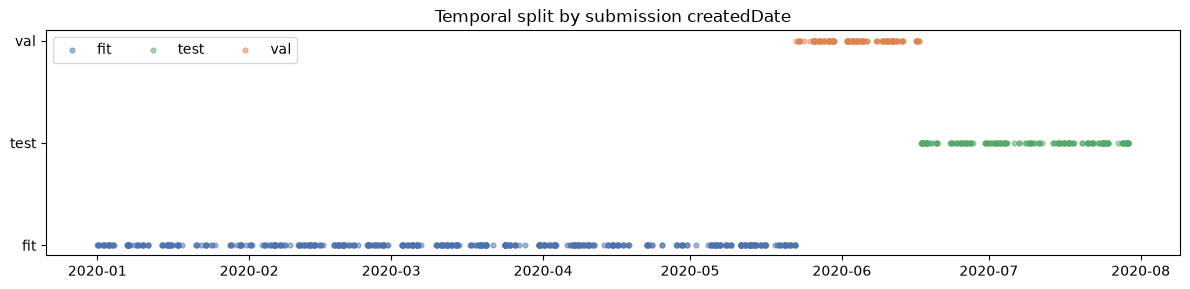

In [123]:
fig, ax = plt.subplots(figsize=(12, 3))
colors = {"fit": "#4C72B0", "val": "#DD8452", "test": "#55A868", "train": "#CCCCCC"}
for split, group in split_map.groupby("split"):
    ax.scatter(group["createdDate"], [split] * len(group), alpha=0.5, s=12, c=colors.get(split, "gray"), label=split)
ax.set_title("Temporal split by submission createdDate")
ax.legend(loc="upper left", ncol=4)
plt.tight_layout()
plt.show()

## 4. Train models & compare candidates

Three model families per horizon (Logistic Regression, Random Forest, XGBoost). For each `t`:

1. **Tune** hyperparameters on the **fit** split — maximize **PR-AUC** (`TimeSeriesSplit` on fit period only).
2. **Select** model type on the **validation** split — maximize **P@20** (tie → val PR-AUC).
3. **Report** ROC-AUC, PR-AUC, and P@20 on the **test** split for **all** candidates (comparison table); test metrics do not change which model is deployed.

Example: at t=0, Random Forest can beat Logistic Regression on **test** P@20, but Logistic Regression wins on **validation** P@20 — we deploy LR because we never select on test data.

In [131]:
from src.train import train_models

training_report = train_models()
print("Training complete.")
for t, info in training_report["horizons"].items():
    tm = info["test_metrics"]
    print(
        f"  t={t} deployed={info['best_model']} "
        f"test P@20={tm['precision_at_top_20']:.1%} PR-AUC={tm['pr_auc']:.3f}"
    )

c:\Users\galin\CascadeProjects\novella\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\galin\CascadeProjects\novella\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\galin\CascadeProjects\novella\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training complete.
  t=0 deployed=logistic_regression test P@20=22.2% PR-AUC=0.244
  t=7 deployed=random_forest test P@20=36.1% PR-AUC=0.431
  t=30 deployed=random_forest test P@20=61.1% PR-AUC=0.708


In [125]:
comparison = pd.DataFrame(training_report["all_model_results"])
comparison["precision_at_top_20"] = comparison["precision_at_top_20"].map(lambda x: f"{x:.1%}")
comparison["val_precision_at_top_20"] = comparison["val_precision_at_top_20"].map(lambda x: f"{x:.1%}")
comparison[[
    "model", "t", "val_precision_at_top_20", "precision_at_top_20", "pr_auc", "roc_auc"
]].sort_values(["t", "model"])

,model,t,val_precision_at_top_20,precision_at_top_20,pr_auc,roc_auc
0,logistic_regression,0,17.2%,22.2%,0.244114,0.566635
1,random_forest,0,6.9%,33.3%,0.356206,0.732742
2,xgboost,0,3.4%,36.1%,0.304532,0.726989
3,logistic_regression,7,27.6%,38.9%,0.403548,0.788351
4,random_forest,7,27.6%,36.1%,0.430545,0.800575
5,xgboost,7,17.2%,25.0%,0.401517,0.695350
6,logistic_regression,30,34.5%,61.1%,0.671859,0.936242
7,random_forest,30,34.5%,61.1%,0.707549,0.945590
8,xgboost,30,34.5%,58.3%,0.670886,0.929171


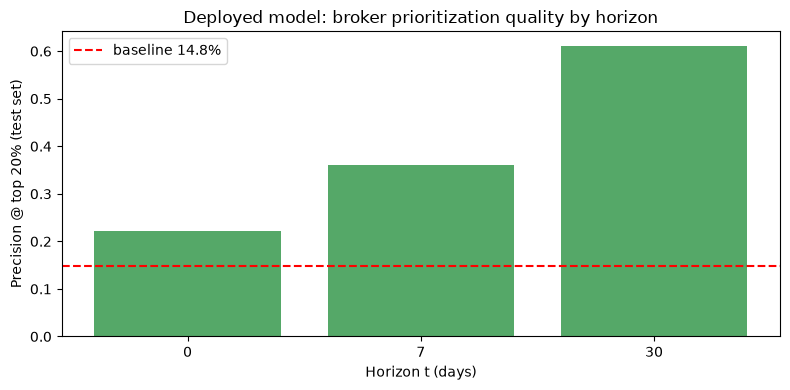

In [126]:
deployed = pd.DataFrame([
    {"t": int(t), "model": info["best_model"], **info["test_metrics"]}
    for t, info in training_report["horizons"].items()
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(deployed["t"].astype(str), deployed["precision_at_top_20"], color="#55A868")
ax.axhline(submissions["label"].mean(), color="red", linestyle="--", label=f"baseline {submissions['label'].mean():.1%}")
ax.set_xlabel("Horizon t (days)")
ax.set_ylabel("Precision @ top 20% (test set)")
ax.set_title("Deployed model: broker prioritization quality by horizon")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature significance (permutation importance)

**Method:** shuffle each feature column (10 repeats), re-score with **PR-AUC** drop (`sklearn.inspection.permutation_importance`, `scoring="average_precision"`).

**Why PR-AUC for importance?** Same scoring function as hyperparameter tuning (§3), so importance reflects contribution under **imbalanced** bind prediction. Unlike tree default impurity, permutation importance is **comparable across model types** (logistic vs forest) and features on different scales.

Reported **per horizon** and as an **overall mean** across t ∈ {0, 7, 30}.

In [127]:
from src.evaluate import run_evaluation

eval_report = run_evaluation(feature_frame, test_ids, MODELS_DIR, OUTPUT_DIR)

overall = pd.DataFrame(eval_report["feature_importance_overall"])
overall["importance_mean"] = overall["importance_mean"].round(3)
overall

,feature,importance_mean
0,agent_smoothed_bind_rate,0.304
1,cumulative_email_density,0.101
2,quote_received_flag,0.074
3,inbound_recency_days,0.066


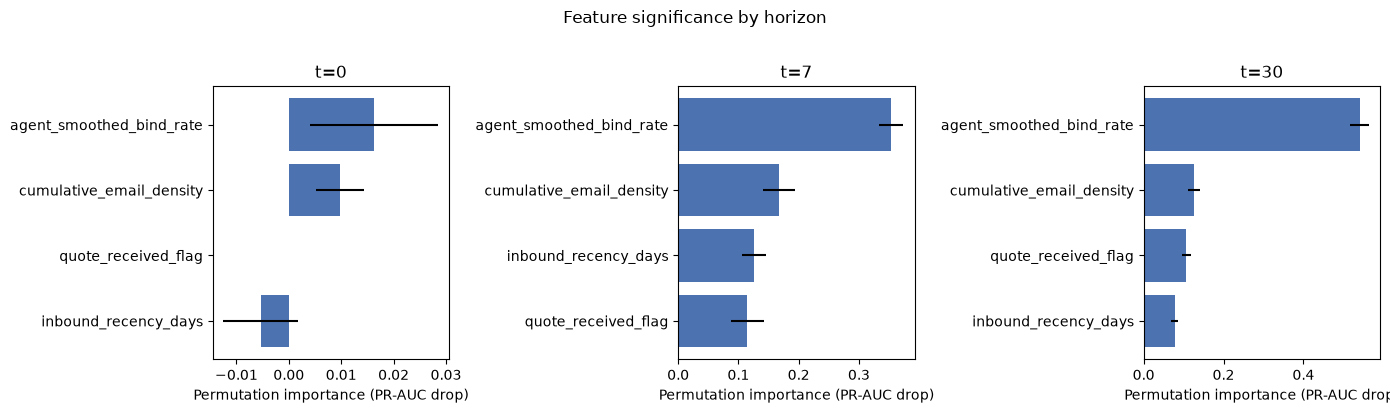

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, t in zip(axes, HORIZONS):
    imp = pd.DataFrame(eval_report["feature_importance"][t])
    ax.barh(imp["feature"], imp["importance_mean"], xerr=imp["importance_std"], color="#4C72B0")
    ax.invert_yaxis()
    ax.set_title(f"t={t}")
    ax.set_xlabel("Permutation importance (PR-AUC drop)")
plt.suptitle("Feature significance by horizon", y=1.02)
plt.tight_layout()
plt.show()

## 6. bind_score(submission_id, t) — challenge API

Returns **P(bind) ∈ [0, 1]**; higher score ⇒ more likely to sell.

In [129]:
from src.bind_score import bind_score

examples = []
for sid in [1, 11, 24]:
    row = {"submissionId": sid, "label": int(submissions.loc[sid, "label"])}
    for t in HORIZONS:
        row[f"score_t{t}"] = bind_score(sid, t)
    examples.append(row)

pd.DataFrame(examples)

,submissionId,label,score_t0,score_t7,score_t30
0,1,0,0.516671,0.495826,0.221408
1,11,1,0.481380,0.563246,0.490942
2,24,1,0.636984,0.555871,0.768534


In [130]:
# Score all test submissions at t=7 and inspect ranking
t = 7
test_subs = submissions[submissions["submissionId"].isin(test_ids)].copy()
test_subs["bind_score"] = test_subs["submissionId"].map(lambda sid: bind_score(int(sid), t))
test_subs = test_subs.sort_values("bind_score", ascending=False)

top_n = max(1, int(np.ceil(len(test_subs) * 0.2)))
precision_top20 = test_subs.head(top_n)["label"].mean()

print(f"Test submissions at t={t}: {len(test_subs)}")
print(f"Precision @ top 20%: {precision_top20:.1%} (baseline {test_subs['label'].mean():.1%})")
test_subs[["submissionId", "createdDate", "label", "bind_score"]].head(10)

Test submissions at t=7: 177
Precision @ top 20%: 36.1% (baseline 15.8%)


,submissionId,createdDate,label,bind_score
submissionId,,,,
835,835,2020-07-22 02:46:52,1,0.786513
747,747,2020-06-25 14:16:51,0,0.739783
717,717,2020-06-18 04:07:29,1,0.732529
791,791,2020-07-09 06:13:46,0,0.730348
873,873,2020-07-29 06:26:00,1,0.696247
875,875,2020-07-29 09:22:45,1,0.685554
736,736,2020-06-23 05:39:19,1,0.678725
705,705,2020-06-17 06:10:54,0,0.676761
761,761,2020-06-30 09:20:56,1,0.676145


## 7. Challenges

Limitations and open issues in this take-home implementation:

| Area | Challenge |
|------|-----------|
| **Data scale** | 881 submissions, ~15% bind rate — small sample; validation P@20 is noisy (~29 submissions in the top-20% slice). |
| **Early horizon** | t=0 has weak signal (test P@20 ~1.5× baseline); brokers get limited lift on day of creation. |
| **Feature set** | Only four hand-engineered features from email/quote/agent fields; no line-of-business, geography, seasonality, or submission content. |
| **Temporal drift** | Single chronological split; patterns may shift — no rolling retrain or drift monitoring yet. |
| **Model selection** | Val metrics do not always align with test (especially at t=0); no nested CV or larger holdout for stable deployment picks. |
| **Probabilities** | `bind_score` is raw `predict_proba` — not calibrated; ranked order is the main product, but absolute probabilities may mislead brokers. |
| **Leakage discipline** | F4 and event cutoffs are handled carefully, but production needs automated leakage tests on every feature change. |
| **Operational gap** | Batch notebook/CLI only — no online scoring service, feature store, or broker-facing UI integration. |

**Artifacts from this notebook:** `models/t_{0,7,30}/model.joblib`, `models/training_report.json`, `output/evaluation_report.json`, `output/feature_importance_t*.png`. CLI: `uv run python main.py run`.

## 8. Future work — production & an ideal bind-score system

To deploy this beyond a take-home and make it production-grade:

**Serving & integration**
- REST/gRPC scoring API (`bind_score(submission_id, t)`) with latency SLOs, auth, and versioning per horizon
- Real-time feature pipeline: ingest events as they arrive, materialize features at T_ref without batch CSV reload
- Broker workflow hook: ranked queue in CRM, explain-why snippet per submission (top features + recency)

**Model quality**
- Richer features: LOB, premium band, carrier, seasonality, email NLP/sentiment, quote turnaround time
- Probability calibration (isotonic / Platt) on a dedicated calibration set; report reliability diagrams
- Stable model selection: nested temporal CV, larger validation window, or optimize blended metric (val PR-AUC + val P@20)
- Ensemble or monotonic constraints if business rules require interpretable ranking
- Continuous retrain on rolling windows; champion/challenger and shadow deployment before cutover

**MLOps & monitoring**
- Feature store + model registry (e.g. MLflow); pinned artifacts per environment
- Monitor: bind rate, score distribution, P@20 on recent cohorts, PR-AUC drift, feature null rates (F1 spikes at t+30)
- Alerts when production P@20 falls below baseline or val/test gap widens
- Automated leakage and temporal-integrity tests in CI (extend `tests/`)

**Governance & product**
- Document broker-facing definition of the score; A/B test prioritization vs current manual triage
- Fairness review across agents/regions; audit trail for scores shown to users
- Feedback loop: log broker actions (worked / skipped / bound) to refine labels and features over time

An **ideal** system scores every open submission within seconds of new events, ranks an actionable top-K queue with calibrated win probabilities, retrains safely on fresh data, and proves lift in broker conversion — not just offline AUC.